# Tutorial Classification

> Tutorial Classification

In [1]:
#| default_exp tutorial_1

In [2]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.core import Path
from bioMONAI.data import get_image_files, get_target, RandomSplitter
from bioMONAI.nets import BasicUNet, DynUNet
from bioMONAI.losses import *
from bioMONAI.metrics import *
from bioMONAI.datasets import download_medmnist

from monai.utils import set_determinism
from monai.transforms import ScaleIntensity

set_determinism(0)

In [3]:
device = get_device()
print(device)

cpu


CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343995622/work/c10/cuda/CUDAFunctions.cpp:109.)


### Download Data

In [11]:
import os
from tqdm import tqdm
from PIL import Image
import medmnist
import tifffile as tiff

def download_medmnist(dataset: str, # The name of the MedMNIST dataset (e.g., 'pathmnist', 'bloodmnist', etc.).
                      output_dir: str = '.', # The path to the directory where the datasets will be saved.
                      download_only: bool = False, # If True, only download the dataset into the output directory without processing.
                      save_images: bool = True, # If True, save the images into the output directory as .png (2D datasets) or multipage .tiff (3D datasets) files.
                      ):
    """
    Downloads the specified MedMNIST dataset and saves the training, validation, and test datasets 
    into the specified output directory. Images are saved as .png for 2D data and multi-page .tiff for 3D data,
    organized into folders named after their labels.

    Args:
    - dataset: The MedMNIST dataset name (e.g., 'pathmnist', 'bloodmnist', etc.).
    - output_dir: Path where the images will be saved.
    - download_only: If True, only downloads the dataset, no processing or saving.
    - save_images: If True, save the images in the specified output directory.

    Returns:
    - None, saves images in the specified output directory if save_images is True.
    """

    # Check if the dataset is available in the MedMNIST information dictionary
    if dataset not in medmnist.INFO:
        raise ValueError(f"The dataset '{dataset}' is not available. Please select from the available datasets.")

    # Retrieve dataset information
    info = medmnist.INFO[dataset]

    # Get the appropriate dataset class from MedMNIST
    dataset_class = getattr(medmnist, info['python_class'])

    # Create the output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Download the datasets
    train_dataset = dataset_class(split='train', download=True, root=output_dir)
    val_dataset = dataset_class(split='val', download=True, root=output_dir)
    test_dataset = dataset_class(split='test', download=True, root=output_dir)

    # Save the images into directories by their label
    def save_images(dataset, split):
        """Helper function to save images and labels into directories."""
        split_dir = os.path.join(output_dir, split)
        if not os.path.exists(split_dir):
            os.makedirs(split_dir)

        for i in tqdm(range(len(dataset))):
            img, label = dataset[i]
            label_dir = os.path.join(split_dir, str(label).replace("[", "").replace("]", ""))  # Remove parentheses
            if not os.path.exists(label_dir):
                os.makedirs(label_dir)

            # Save 2D images as .png
            if info['n_channels'] == 1:  # Check if it's 2D (single-channel)
                img_path = os.path.join(label_dir, f'{split}_{i}.png')
                img = Image.fromarray(img.squeeze(), mode='L')  # 'L' mode for grayscale
                img.save(img_path)
            elif info['n_channels'] == 3:  # Check if it's RGB
                img_path = os.path.join(label_dir, f'{split}_{i}.png')
                # img = Image.fromarray(img, mode='RGB')  # Convert to HWC format for RGB
                img.save(img_path)
            # Save 3D images as multi-page .tiff
            else:
                img_path = os.path.join(label_dir, f'{split}_{i}.tiff')
                tiff.imwrite(img_path, img)

    # Save training, validation, and test data if save_images is True
    if save_images:
        print(f"Saving training images to {output_dir}...")
        save_images(train_dataset, 'train')

        print(f"Saving validation images to {output_dir}...")
        save_images(val_dataset, 'val')

        print(f"Saving test images to {output_dir}...")
        save_images(test_dataset, 'test')
        
        # Clean up: remove .npz files if present
        for file in os.listdir(output_dir):
            if file.endswith('.npz'):
                os.remove(os.path.join(output_dir, file))
                print(f"Removed {file}")

    # If download_only is True, skip returning the dataset objects and just download the files
    if download_only:
        print(f"Datasets downloaded to {output_dir}")
        print(f"Dataset info for '{dataset}': {info}")
        return info

    # Return the datasets if download_only is False and save_images is False
    return train_dataset, val_dataset, test_dataset if not save_images else None






In [12]:
image_path = '../_data/medmnist_data/'
info = download_medmnist('bloodmnist', image_path, download_only=True)
info

Using downloaded and verified file: ../_data/medmnist_data/bloodmnist.npz
Using downloaded and verified file: ../_data/medmnist_data/bloodmnist.npz
Using downloaded and verified file: ../_data/medmnist_data/bloodmnist.npz
Saving training images to ../_data/medmnist_data/...


100%|██████████| 11959/11959 [00:02<00:00, 5533.95it/s]


Saving validation images to ../_data/medmnist_data/...


100%|██████████| 1712/1712 [00:00<00:00, 5644.32it/s]


Saving test images to ../_data/medmnist_data/...


100%|██████████| 3421/3421 [00:00<00:00, 5632.64it/s]

Removed bloodmnist.npz
Datasets downloaded to ../_data/medmnist_data/
Dataset info for 'bloodmnist': {'python_class': 'BloodMNIST', 'description': 'The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.', 'url': 'https://zenodo.org/records/10519652/files/bloodmnist.npz?download=1', 'MD5': '7053d0359d879ad8a5505303e11de1dc', 'url_64': 'https://zenodo.org/records/10519652/files/bloodmnist_64.npz?download=1', 'MD5_64': '2b94928a2ae4916078ca51e05b6b800b', 'url_128': 'https://zenodo.org/records/10519652/files/bloodmnist_128.npz?download=1', 'MD5_128': 'adace1

{'python_class': 'BloodMNIST',
 'description': 'The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/bloodmnist.npz?download=1',
 'MD5': '7053d0359d879ad8a5505303e11de1dc',
 'url_64': 'https://zenodo.org/records/10519652/files/bloodmnist_64.npz?download=1',
 'MD5_64': '2b94928a2ae4916078ca51e05b6b800b',
 'url_128': 'https://zenodo.org/records/10519652/files/bloodmnist_128.npz?download=1',
 'MD5_128': 'adace1e0ed228fccda1f39692059dd4c',
 'url_224': 'https://zenodo.org/records/10519652/files/bloodmnist

### Create Dataloader

In [5]:
from fastai.vision.all import *

In [13]:
bs, size = 4, 128

path = Path(image_path)
path_train = path/'train'
path_val = path/'val'


data_ops = {
    'blocks':       (BioImageBlock(cls=BioImageMulti), CategoryBlock(vocab=info['label'])),
    'get_items':    get_image_files,
    'get_y':        parent_label,
    'splitter':     GrandparentSplitter(),
    'item_tfms':    [],
    'bs': bs,
}

data = get_dataloader(
    path, 
    show_summary=True,
    **data_ops,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.


Setting-up type transforms pipelines
Found 17092 items
2 datasets of sizes 13674,3418
Setting up Pipeline: BioImageMulti.create -> Tensor2BioImage -- {}
Setting up Pipeline: parent_label -> Categorize -- {'vocab': ['0', '1', '2', '3', '4', '5', '6', '7'], 'sort': True, 'add_na': False}

Building one sample
  Pipeline: BioImageMulti.create -> Tensor2BioImage -- {}
    starting from
      ../_data/medmnist_data/train/3/train_6681.png
    applying BioImageMulti.create gives
      BioImageMulti of size 3x28x28x1
    applying Tensor2BioImage -- {} gives
      BioImageMulti of size 3x28x28x1
  Pipeline: parent_label -> Categorize -- {'vocab': ['0', '1', '2', '3', '4', '5', '6', '7'], 'sort': True, 'add_na': False}
    starting from
      ../_data/medmnist_data/train/3/train_6681.png
    applying parent_label gives
      3
    applying Categorize -- {'vocab': ['0', '1', '2', '3', '4', '5', '6', '7'], 'sort': True, 'add_na': False} gives
      TensorCategory(3)

Final sample: (BioImageMulti([[

Setting affine, but the applied meta contains an affine. This will be overwritten.


Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.


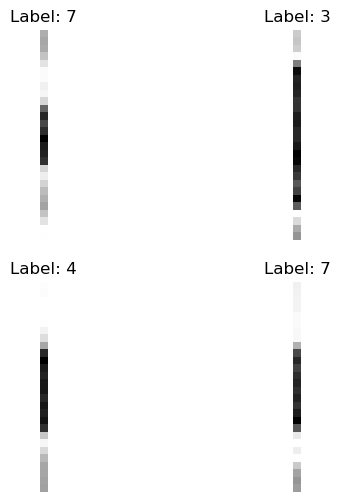

In [14]:
data.show_batch(max_n=4)

### Load and train a 2D model

In [ ]:
from monai.networks.nets import densenet121

In [15]:
# model = densenet121(spatial_dims=2, in_channels=1, out_channels=8)
 
loss = CrossEntropyLossFlat()
# metrics = [SSIMMetric, MSELoss]

# trainer = fastTrainer(data, model, loss_fn=loss, metrics=metrics, show_summary=False)

trainer = vision_learner(data, resnet18, loss_func=loss, metrics=partial(accuracy_multi, thresh=0.5))

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.


In [16]:
trainer.fit(1)

epoch,train_loss,valid_loss,accuracy_multi,time


Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Sett

RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [4, 3, 28, 28, 1]

In [ ]:
trainer.show_results(cmap='gray')

In [ ]:
# trainer.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!